In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from xgboost import XGBClassifier   


from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [34]:
df = pd.read_csv('data/raw.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [35]:
df.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [36]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.drop('Name', axis=1, inplace=True)

In [37]:
df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [38]:
df['Title'] = df['Title'].replace([
    'Lady', 'Countess','Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer'
], 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

In [39]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize
0,0,3,male,22,1,0,7.2500,S,Mr,2
1,1,1,female,38,1,0,71.2833,C,Mrs,2
2,1,3,female,26,0,0,7.9250,S,Miss,1
3,1,1,female,35,1,0,53.1000,S,Mrs,2
4,0,3,male,35,0,0,8.0500,S,Mr,1


In [40]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [41]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    714 non-null    int64  
 1   Pclass      714 non-null    int64  
 2   Sex         714 non-null    object 
 3   Age         714 non-null    int64  
 4   SibSp       714 non-null    int64  
 5   Parch       714 non-null    int64  
 6   Fare        714 non-null    float64
 7   Embarked    714 non-null    object 
 8   Title       714 non-null    object 
 9   FamilySize  714 non-null    int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 55.9+ KB


In [43]:
num_features = X.select_dtypes(exclude=['object']).columns
cat_features = X.select_dtypes(include=['object']).columns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(drop='first', dtype=int)

preprocessor = ColumnTransformer(
    transformers=[
        ("OneHotEncoder", cat_transformer, cat_features),
        ("StandardScaler", num_transformer, num_features)
    ]
)


In [44]:
X = preprocessor.fit_transform(X)

In [45]:
X.shape

(714, 13)

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((571, 13), (143, 13))

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

def evaluate_model(y_true, y_pred, y_pred_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba) if y_pred_proba is not None else None
    
    return accuracy, precision, recall, f1, roc_auc

In [48]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'CatBoost': CatBoostClassifier(verbose=0),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}
model_list = []
results = []

for name, model in models.items():
    print(f"🔹 Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Handle predict_proba safely
    if hasattr(model, "predict_proba"):
        y_train_prob = model.predict_proba(X_train)[:, 1]
        y_test_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_train_prob = None
        y_test_prob = None

    # Evaluation
    train_metrics = evaluate_model(y_train, y_train_pred, y_train_prob)
    test_metrics = evaluate_model(y_test, y_test_pred, y_test_prob)

    train_acc, train_prec, train_rec, train_f1, train_roc_auc = train_metrics
    test_acc, test_prec, test_rec, test_f1, test_roc_auc = test_metrics

    # Store results
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
        "Test ROC-AUC": test_roc_auc
    })

    # Print details
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")
    if train_roc_auc is not None and test_roc_auc is not None:
        print(f"ROC-AUC: Train {train_roc_auc:.4f} | Test {test_roc_auc:.4f}\n")
    else:
        print("ROC-AUC: Not available for this model\n")
    print("📊 Classification Report:")
    print(classification_report(y_test, y_test_pred))

    print("📉 Confusion Matrix:")
    print(confusion_matrix(y_test, y_test_pred))
    
    print("-" * 60)

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by best model
results_df = results_df.sort_values(by="Test F1", ascending=False)

print("\n🏆 Model Comparison:")
print(results_df)


🔹 Training Logistic Regression...


LogisticRegression()

Train Accuracy: 0.8266 | Test Accuracy: 0.8042
ROC-AUC: Train 0.8789 | Test 0.8554

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        87
           1       0.77      0.71      0.74        56

    accuracy                           0.80       143
   macro avg       0.80      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143

📉 Confusion Matrix:
[[75 12]
 [16 40]]
------------------------------------------------------------
🔹 Training Random Forest...


RandomForestClassifier()

Train Accuracy: 0.9912 | Test Accuracy: 0.7832
ROC-AUC: Train 0.9996 | Test 0.8417

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        87
           1       0.73      0.71      0.72        56

    accuracy                           0.78       143
   macro avg       0.77      0.77      0.77       143
weighted avg       0.78      0.78      0.78       143

📉 Confusion Matrix:
[[72 15]
 [16 40]]
------------------------------------------------------------
🔹 Training AdaBoost...


...

CatBoostClassifier(verbose=0)

Train Accuracy: 0.9124 | Test Accuracy: 0.8042
ROC-AUC: Train 0.9618 | Test 0.8386

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        87
           1       0.77      0.71      0.74        56

    accuracy                           0.80       143
   macro avg       0.80      0.79      0.79       143
weighted avg       0.80      0.80      0.80       143

📉 Confusion Matrix:
[[75 12]
 [16 40]]
------------------------------------------------------------
🔹 Training XGBoost...


/Users/rss/Documents/End_to_End_Projects/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:59:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

Train Accuracy: 0.9825 | Test Accuracy: 0.8112
ROC-AUC: Train 0.9993 | Test 0.8599

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85        87
           1       0.80      0.70      0.74        56

    accuracy                           0.81       143
   macro avg       0.81      0.79      0.80       143
weighted avg       0.81      0.81      0.81       143

📉 Confusion Matrix:
[[77 10]
 [17 39]]
------------------------------------------------------------

🏆 Model Comparison:
                 Model  Train Accuracy  Test Accuracy   Test F1  Test ROC-AUC
5                  SVM        0.838879       0.818182  0.754717           NaN
3    Gradient Boosting        0.915937       0.804196  0.745455      0.854885
4                  KNN        0.866900       0.804196  0.745455      0.819479
8              XGBoost        0.982487       0.811189  0.742857      0.859914
0  Logistic Regression        0.826620       0.804196

<Figure size 1200x600 with 0 Axes>

/var/folders/10/0s1cyptd1235lncy2hq7h6gh0000gn/T/ipykernel_93280/1647344989.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test F1", data=results_df, palette="viridis")


<Axes: xlabel='Model', ylabel='Test F1'>

Text(0.5, 1.0, 'Model Comparison - Test F1 Score')

([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'SVM'),
  Text(1, 0, 'Gradient Boosting'),
  Text(2, 0, 'KNN'),
  Text(3, 0, 'XGBoost'),
  Text(4, 0, 'Logistic Regression'),
  Text(5, 0, 'CatBoost'),
  Text(6, 0, 'Random Forest'),
  Text(7, 0, 'AdaBoost'),
  Text(8, 0, 'Decision Tree')])

Text(0, 0.5, 'Test F1 Score')

Text(0.5, 0, 'Model')

(0.0, 1.0)

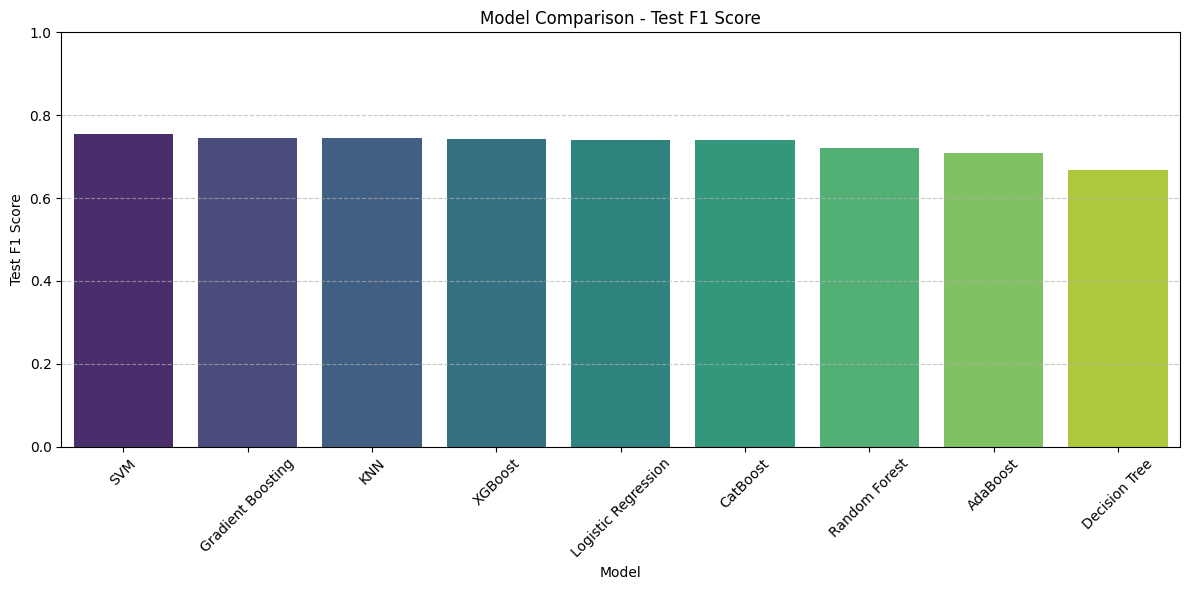

In [49]:
## Plotting results
plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Test F1", data=results_df, palette="viridis")
plt.title("Model Comparison - Test F1 Score")
plt.xticks(rotation=45)
plt.ylabel("Test F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()